<a href="https://colab.research.google.com/github/denverkim/ALGORITHM/blob/main/ALGORITHM_LAB10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn import datasets

iris = datasets.load_iris()
iris.data # 꽃의 속성

In [3]:
iris.target # 꽃의 종

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
iris.target_names # 꽃의 종류

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
print(iris.DESCR) # 데이터 설명

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [9]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [10]:
# 데이터 프레임 만들기
import pandas as pd
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [14]:
df.dtypes # 분석방향 -> 분류 알고리즘 사용

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
target,int64


In [11]:
# x and y split
y = df['target']
x = df.drop('target', axis=1)

In [18]:
# 훈련, 테스트 데이터 분리
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [17]:
# 의사결정트리모델
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(x_train, y_train) # 훈련 데이터로 모델 만들기

DecisionTreeClassifier()

In [21]:
# 정확도 평가
print(dt.score(x_test, y_test))

from sklearn.metrics import accuracy_score
y_pred = dt.predict(x_test)
print(accuracy_score(y_test, y_pred))

1.0
1.0


In [26]:
# 교차검증
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(dt, x_test, y_test, scoring='accuracy', cv=10)
dt_cv.mean(), dt_cv.std()

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


(np.float64(0.9666666666666666), np.float64(0.1))

In [27]:
# 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [28]:
rf.score(x_test, y_test)

0.9666666666666667

In [30]:
rf_cv = cross_val_score(rf, x_test, y_test, scoring='accuracy', cv=10)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


In [32]:
# Create 5 machine learning models, pick the best and build confidence that the accuracy is reliable. 아이리스 데이터를 가지고 머신러닝 모델을 개발한 후 성능비교
# §Build DT, RF, LDA, kNN, and SVM models. 5개 모델 구축
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)
lda_cv = cross_val_score(lda, x_test, y_test, scoring='accuracy', cv=10)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
knn_cv = cross_val_score(knn, x_test, y_test, scoring='accuracy', cv=10)

from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train, y_train)
svm_cv = cross_val_score(svm, x_test, y_test, scoring='accuracy', cv=10)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


In [39]:
# §Use 10-fold cross validation to compare the models. 교차검증을 사용하여 모델비교

summary = pd.DataFrame({'DT': dt_cv, 'RF': rf_cv, 'LDA': lda_cv, 'KNN': knn_cv, 'SVM': svm_cv})

import matplotlib.pyplot as plt

summary_mean = summary.mean()
summary_std = summary.std()

pd.DataFrame({'정확도 평균': summary_mean,
              '정확도 표준편차': summary_std})

,정확도 평균,정확도 표준편차
DT,0.966667,0.105409
RF,0.933333,0.140546
LDA,0.966667,0.105409
KNN,1.000000,0.000000
SVM,0.966667,0.105409


<Axes: >

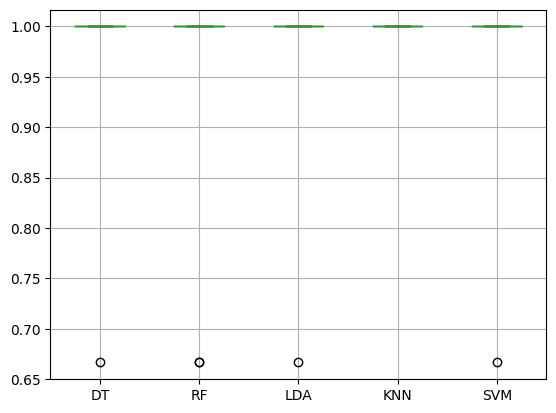

In [40]:
summary.boxplot()

In [44]:
# §Predict with actual data. 실데이터를 가지고 예측하기

knn.predict(x_test.iloc[:2])

array([1, 1])

In [46]:
x_test.iloc[1]

,79
sepal length (cm),5.7
sepal width (cm),2.6
petal length (cm),3.5
petal width (cm),1.0
